<a href="https://colab.research.google.com/github/rahafalnjjar49-cloud/Robot-simulation/blob/main/GarBage_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import drive
import zipfile
import os
import shutil

drive.mount('/content/drive', force_remount=True)

zip_path = '/content/drive/MyDrive/datasets/archive(8).zip'
extract_path = '/content/data'

if not os.path.exists(zip_path):
    print(f"❌ الخطأ: الملف غير موجود في المسار: {zip_path}")
    print("📁 محتويات مجلد datasets:")
    datasets_path = '/content/drive/MyDrive/datasets'
    if os.path.exists(datasets_path):
        for item in os.listdir(datasets_path):
            print(f"  - {item}")
    else:
        print("❌ مجلد datasets غير موجود في MyDrive")
else:
    os.makedirs(extract_path, exist_ok=True)
    shutil.copy(zip_path, '/content/dataset.zip')

    with zipfile.ZipFile('/content/dataset.zip', 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print("✅ تم فك الضغط بنجاح")
    print("📁 محتويات data:", os.listdir(extract_path))

Mounted at /content/drive
✅ تم فك الضغط بنجاح
📁 محتويات data: ['original', 'standardized_384', 'standardized_256']


In [ ]:
import os
import torchvision
from torchvision import transforms

IMG_SIZE = 128

train_transform  = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
])


DATA_DIR = '/content/data'

def find_class_root(root):
    for dirpath, dirnames, filenames in os.walk(root):
        if len(dirnames) >= 5:
            return dirpath
    return root

DATA_DIR = find_class_root(DATA_DIR)
print("مسار الفئات:", DATA_DIR)
print("الفئات الموجودة:", sorted(os.listdir(DATA_DIR)))

full_dataset_train = torchvision.datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
full_dataset_eval  = torchvision.datasets.ImageFolder(root=DATA_DIR, transform=val_test_transform)

class_names = full_dataset_train.classes
NUM_CLASSES = len(class_names)
print("عدد الصور الكلي:", len(full_dataset_train))
print("الفئات:", class_names)

مسار الفئات: /content/data/original
الفئات الموجودة: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
عدد الصور الكلي: 12259
الفئات: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [ ]:
import torch
from torch.utils.data import random_split, DataLoader

n_total = len(full_dataset_train)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_ds, _, _ = random_split(
    full_dataset_train, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)
_, val_ds, test_ds = random_split(
    full_dataset_eval, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)
print("Train:", len(train_ds), " Val:", len(val_ds), " Test:", len(test_ds))

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

Train: 8581  Val: 1838  Test: 1840


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import torch
import torch.nn as nn


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)


        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = self.relu(out)
        return out



In [ ]:
class ResNetScratch(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.layer1 = ResidualBlock(64,  64,  stride=1)
        self.layer2 = ResidualBlock(64,  128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)
        self.layer4 = ResidualBlock(256, 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNetScratch(num_classes=NUM_CLASSES).to(device)
print(model)

ResNetScratch(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer1): ResidualBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential()
  )
  (layer2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (conv2)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3 , weight_decay=1e-4)

EPOCHS = 30

def evaluate_loader(loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss_sum += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return loss_sum / total, correct / total

for epoch in range(EPOCHS):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        running_correct += (outputs.argmax(dim=1) == labels).sum().item()
        running_total += labels.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    val_loss, val_acc = evaluate_loader(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} - "
          f"train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")


Epoch 1/30 - train_loss: 1.8772 train_acc: 0.3456 - val_loss: 1.7514 val_acc: 0.4113
Epoch 2/30 - train_loss: 1.6648 train_acc: 0.4130 - val_loss: 1.9328 val_acc: 0.4026
Epoch 3/30 - train_loss: 1.5701 train_acc: 0.4550 - val_loss: 1.7187 val_acc: 0.4347
Epoch 4/30 - train_loss: 1.4823 train_acc: 0.4847 - val_loss: 1.6174 val_acc: 0.4472
Epoch 5/30 - train_loss: 1.4277 train_acc: 0.5033 - val_loss: 1.4969 val_acc: 0.4995
Epoch 6/30 - train_loss: 1.3619 train_acc: 0.5230 - val_loss: 1.9251 val_acc: 0.3819
Epoch 7/30 - train_loss: 1.3021 train_acc: 0.5524 - val_loss: 1.7696 val_acc: 0.4189
Epoch 8/30 - train_loss: 1.2679 train_acc: 0.5629 - val_loss: 1.4588 val_acc: 0.5223
Epoch 9/30 - train_loss: 1.2179 train_acc: 0.5802 - val_loss: 1.6591 val_acc: 0.4826
Epoch 10/30 - train_loss: 1.1806 train_acc: 0.5934 - val_loss: 1.1949 val_acc: 0.6045
Epoch 11/30 - train_loss: 1.1201 train_acc: 0.6206 - val_loss: 1.9745 val_acc: 0.4178
Epoch 12/30 - train_loss: 1.0938 train_acc: 0.6305 - val_loss: 

Test Accuracy: 0.7771739130434783

              precision    recall  f1-score   support

     battery     0.8099    0.9074    0.8559       108
  biological     0.7565    0.8614    0.8056       101
   cardboard     0.8128    0.8306    0.8216       183
     clothes     0.8904    0.8993    0.8948       298
       glass     0.7925    0.7394    0.7650       284
       metal     0.6370    0.5931    0.6143       145
       paper     0.8194    0.6020    0.6941       196
     plastic     0.6680    0.7793    0.7193       222
       shoes     0.7519    0.8622    0.8033       225
       trash     0.8000    0.5641    0.6617        78

    accuracy                         0.7772      1840
   macro avg     0.7738    0.7639    0.7636      1840
weighted avg     0.7804    0.7772    0.7746      1840



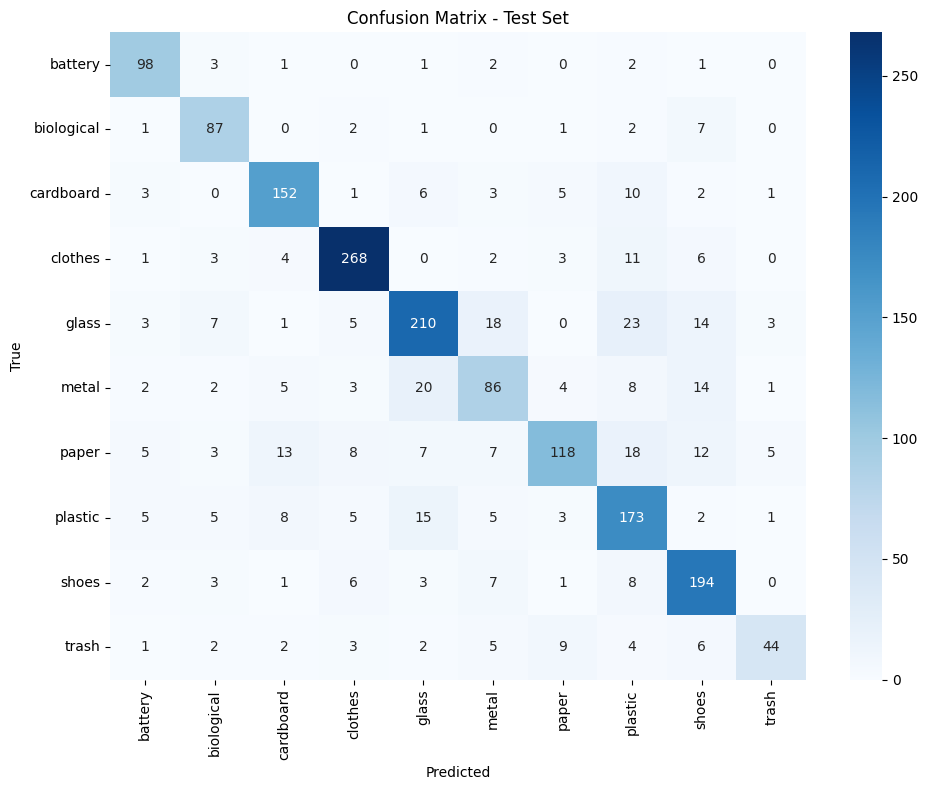

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Test Accuracy:", accuracy_score(y_true, y_pred))
print()
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(), "garbage_resnet_scratch.pt")

import pickle
with open("class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)

print("تم الحفظ بنجاح.")

تم الحفظ بنجاح.


In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
from PIL import Image
import torch

model.eval()

def predict(input_image):
    img = Image.fromarray(input_image).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    tensor = val_test_transform(img).unsqueeze(0).to(device)   # << التصحيح هنا

    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    return {class_names[i]: float(probs[i]) for i in range(len(class_names))}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="numpy", label="ارفع صورة للنفايات"),
    outputs=gr.Label(num_top_classes=len(class_names), label="النتيجة"),
    title="تصنيف النفايات",
    description="ارفع صورة لعنصر نفايات وسيصنّفه النموذج ضمن الفئات المتاحة."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5c7726b952a6583c1b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
